
image 1/1 /content/girl.avif: 448x640 1 person, 421.8ms
Speed: 14.4ms preprocess, 421.8ms inference, 44.1ms postprocess per image at shape (1, 3, 448, 640)
person: 0.74 at [3, 7, 593, 486]


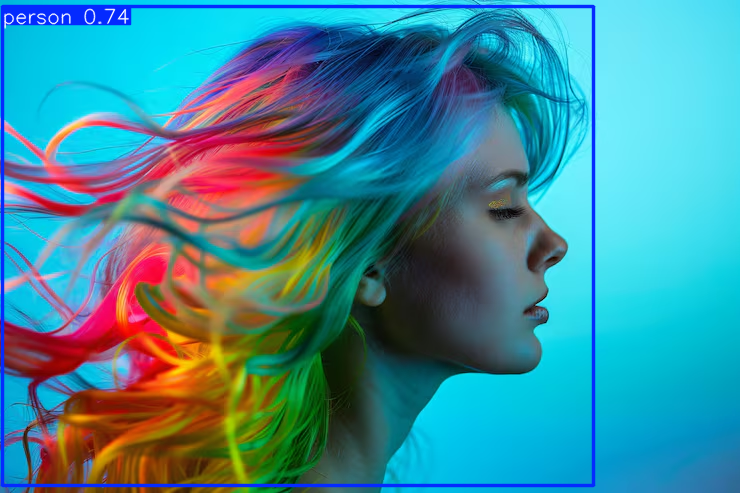

In [2]:
# Install library (run once in Colab)
!pip install ultralytics

# Import libraries
from ultralytics import YOLO
import cv2
from google.colab.patches import cv2_imshow

# Load pretrained YOLOv8 Nano model
model = YOLO('yolov8n.pt')

# Run detection on image
results = model('/content/girl.avif', conf=0.5)

# Process detection results
for result in results:
    boxes = result.boxes

    for box in boxes:
        x1, y1, x2, y2 = box.xyxy[0].tolist()
        conf = box.conf[0].item()
        cls_id = int(box.cls[0].item())
        cls_name = model.names[cls_id]

        print(f'{cls_name}: {conf:.2f} at [{x1:.0f}, {y1:.0f}, {x2:.0f}, {y2:.0f}]')

# Show image with bounding boxes
annotated = results[0].plot()
cv2_imshow(annotated)